[2026-08-05 18:33:55] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-08-05 18:33:58] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-08-05 18:33:58] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-08-05 18:33:58] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-08-05 18:33:58] [info     ] ========== 数据检查 ==========
[2026-08-05 18:33:58] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'debt_to_asset_lf', 'current_ratio_lf', 'netflow_amount_main', 'netflow_amount_rate_main', 'net_act

时段,IC
2024-01-15~2024-02-08,0.0120
2024-09-24~2024-10-08,0.0304

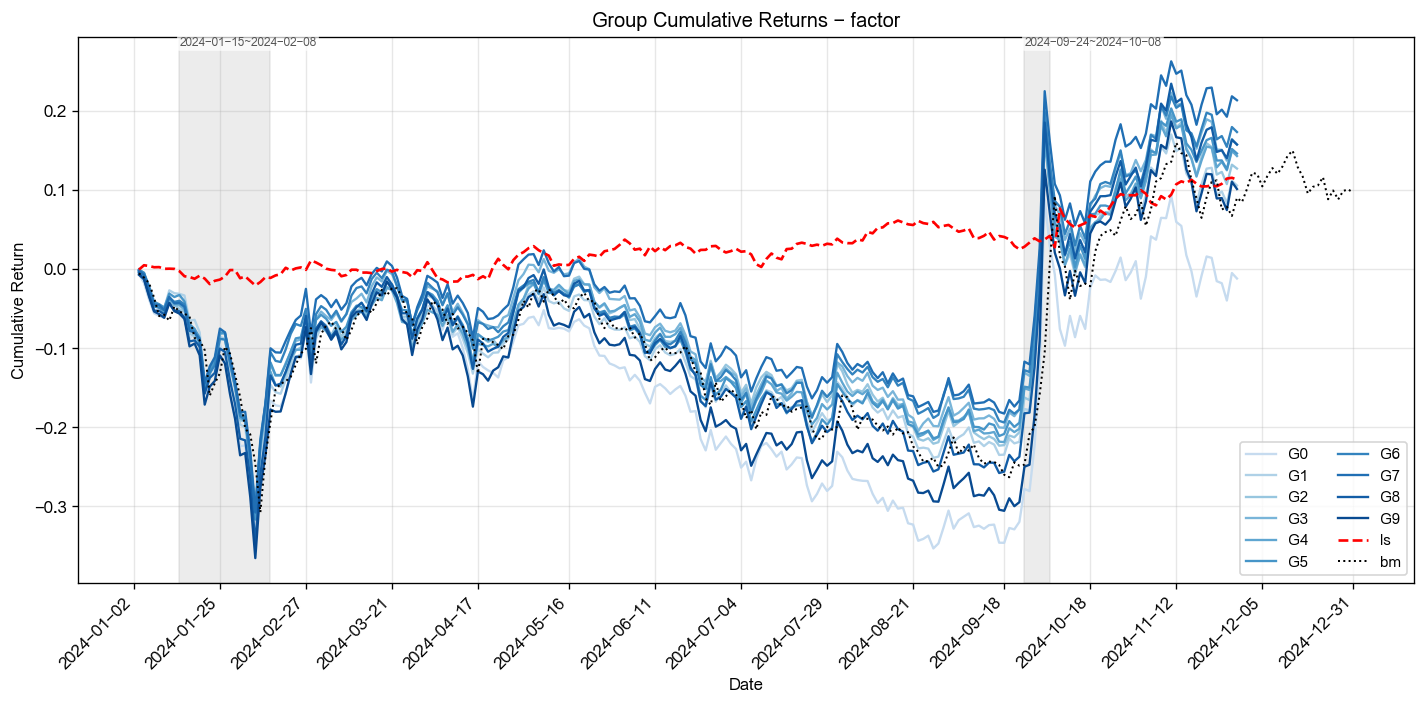
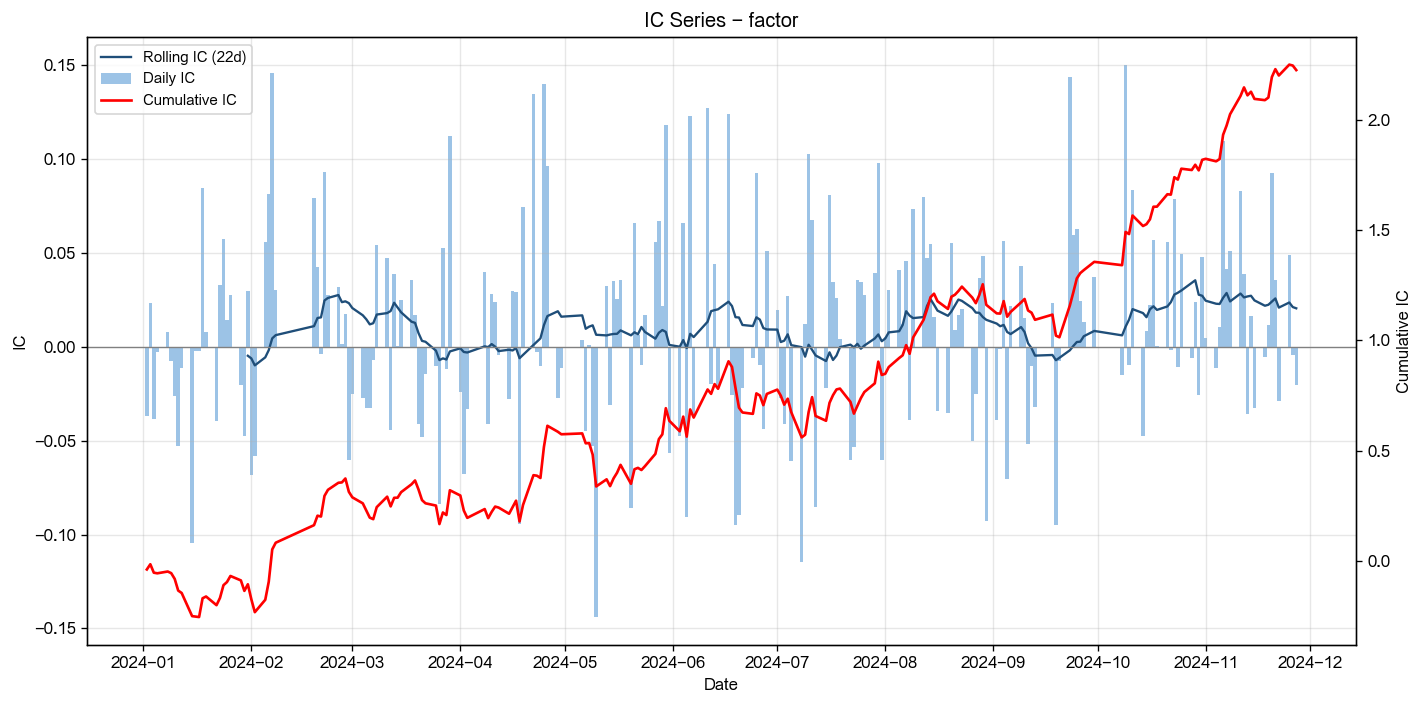
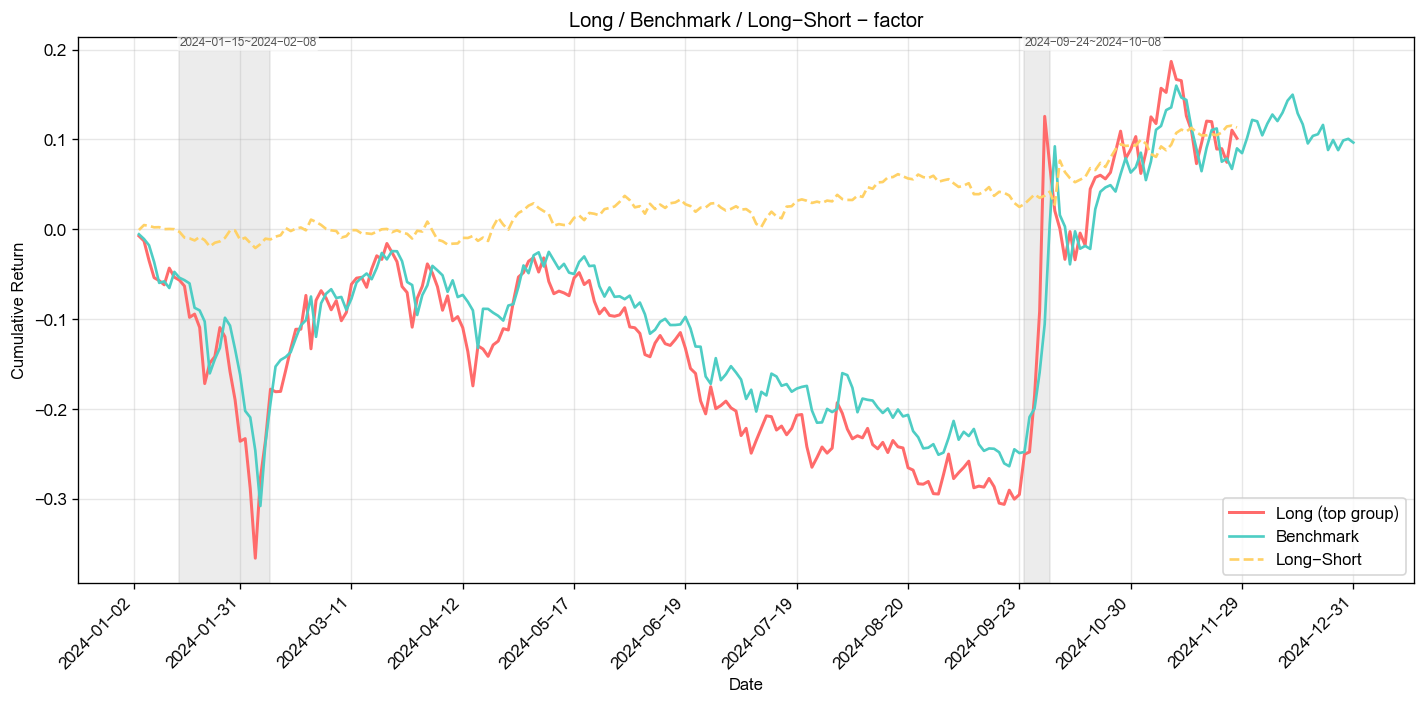
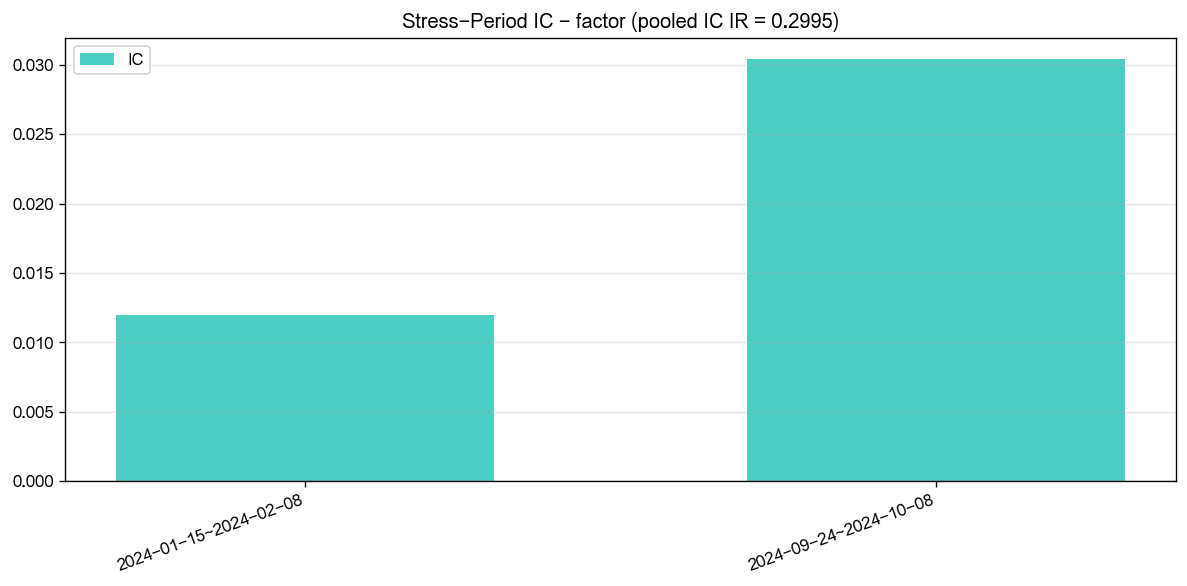
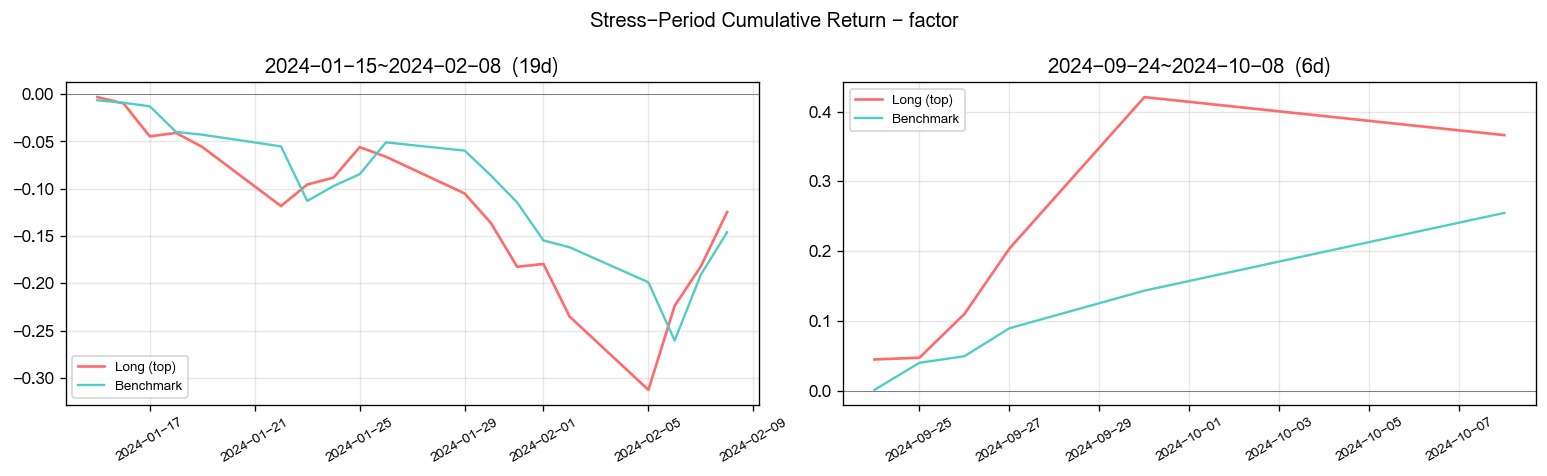

[2026-08-05 18:34:11] [info     ] ========== 因子池回归 ==========
[2026-08-05 18:34:11] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-08-05 18:34:13] [info     ] 获取收益率数据, 耗时: 2.3002 秒
[2026-08-05 18:34:14] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.5994 秒
[2026-08-05 18:34:14] [info     ] 统计 回归结果, 耗时: 0.0894 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.8642,0.0450,0.0241,1.0000
2,amount,1.7203,0.0186,0.0108,0.9000
3,netflow_amount_rate_main,1.5263,0.0099,0.0065,1.0000
4,netflow_amount_main,1.5208,0.0254,0.0167,1.0000
5,gross_profit_rate_ttm,1.5194,0.0070,0.0046,1.0000
6,net_profit_rate_ttm,1.4435,0.0040,0.0028,0.8000
7,bias_20,1.4228,0.0295,0.0207,0.9000
8,pb,1.4227,0.0097,0.0068,1.0000
9,factor,1.3813,0.0065,0.0047,1.0000
10,cci_14,1.3561,0.0336,0.0248,1.0000

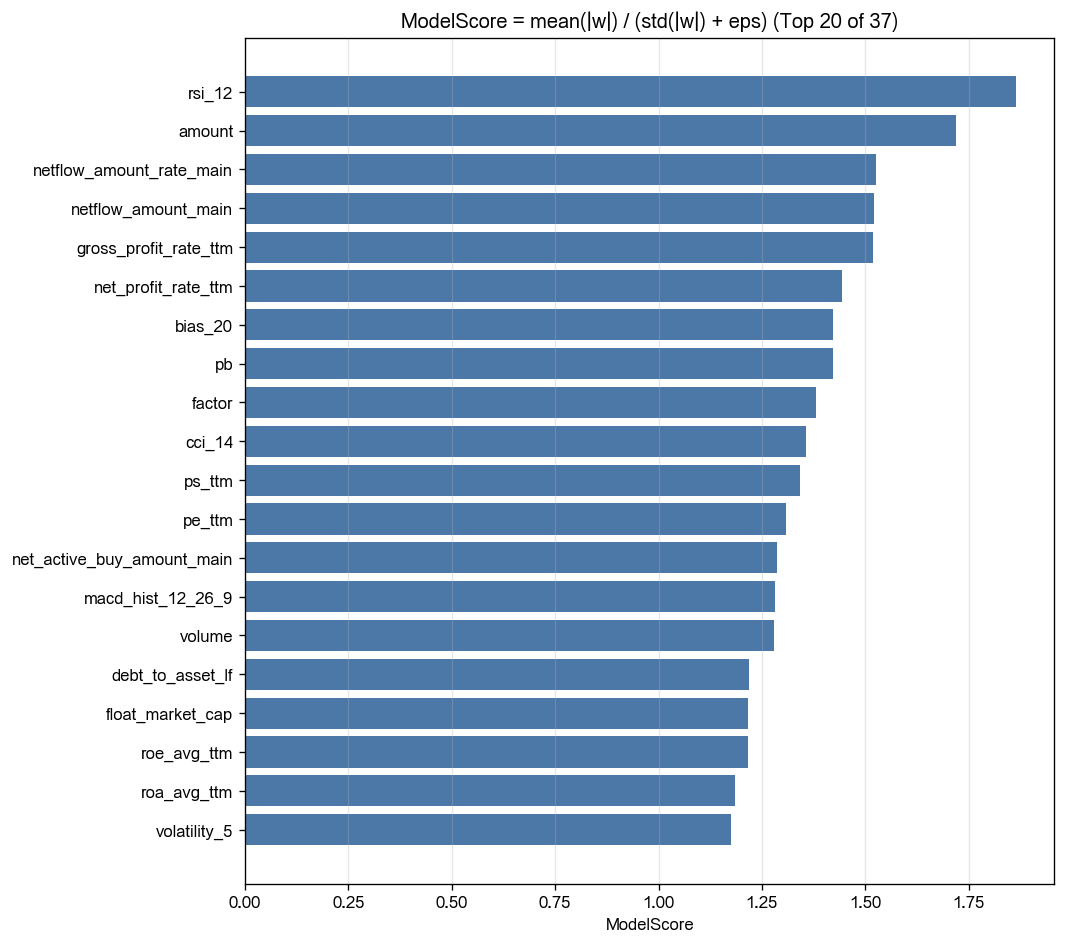
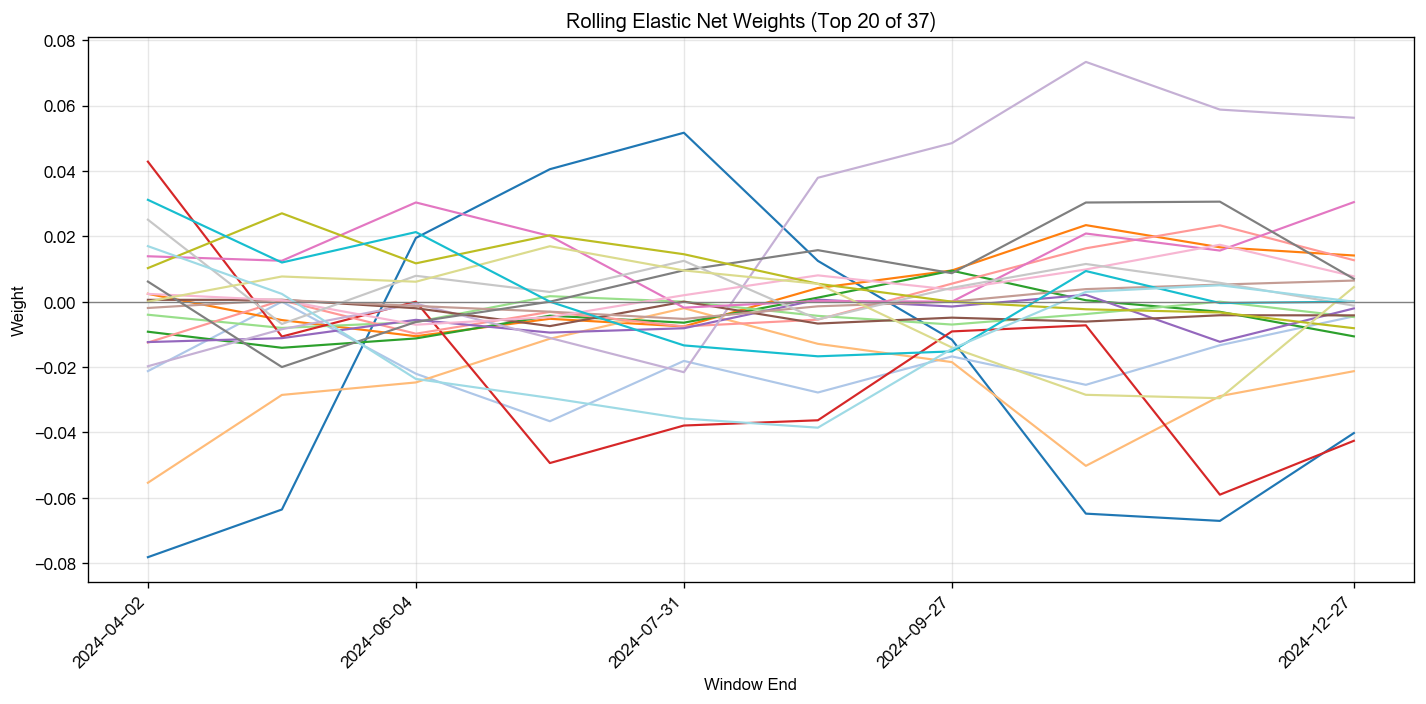
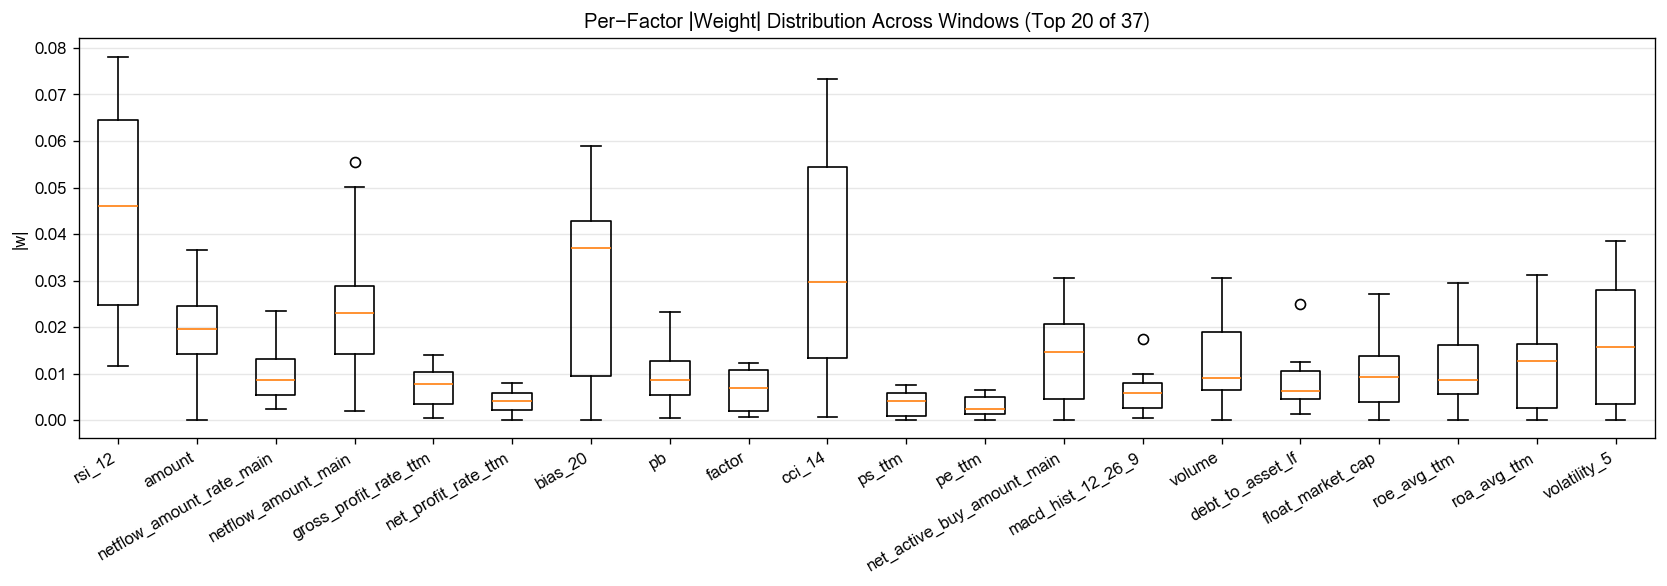
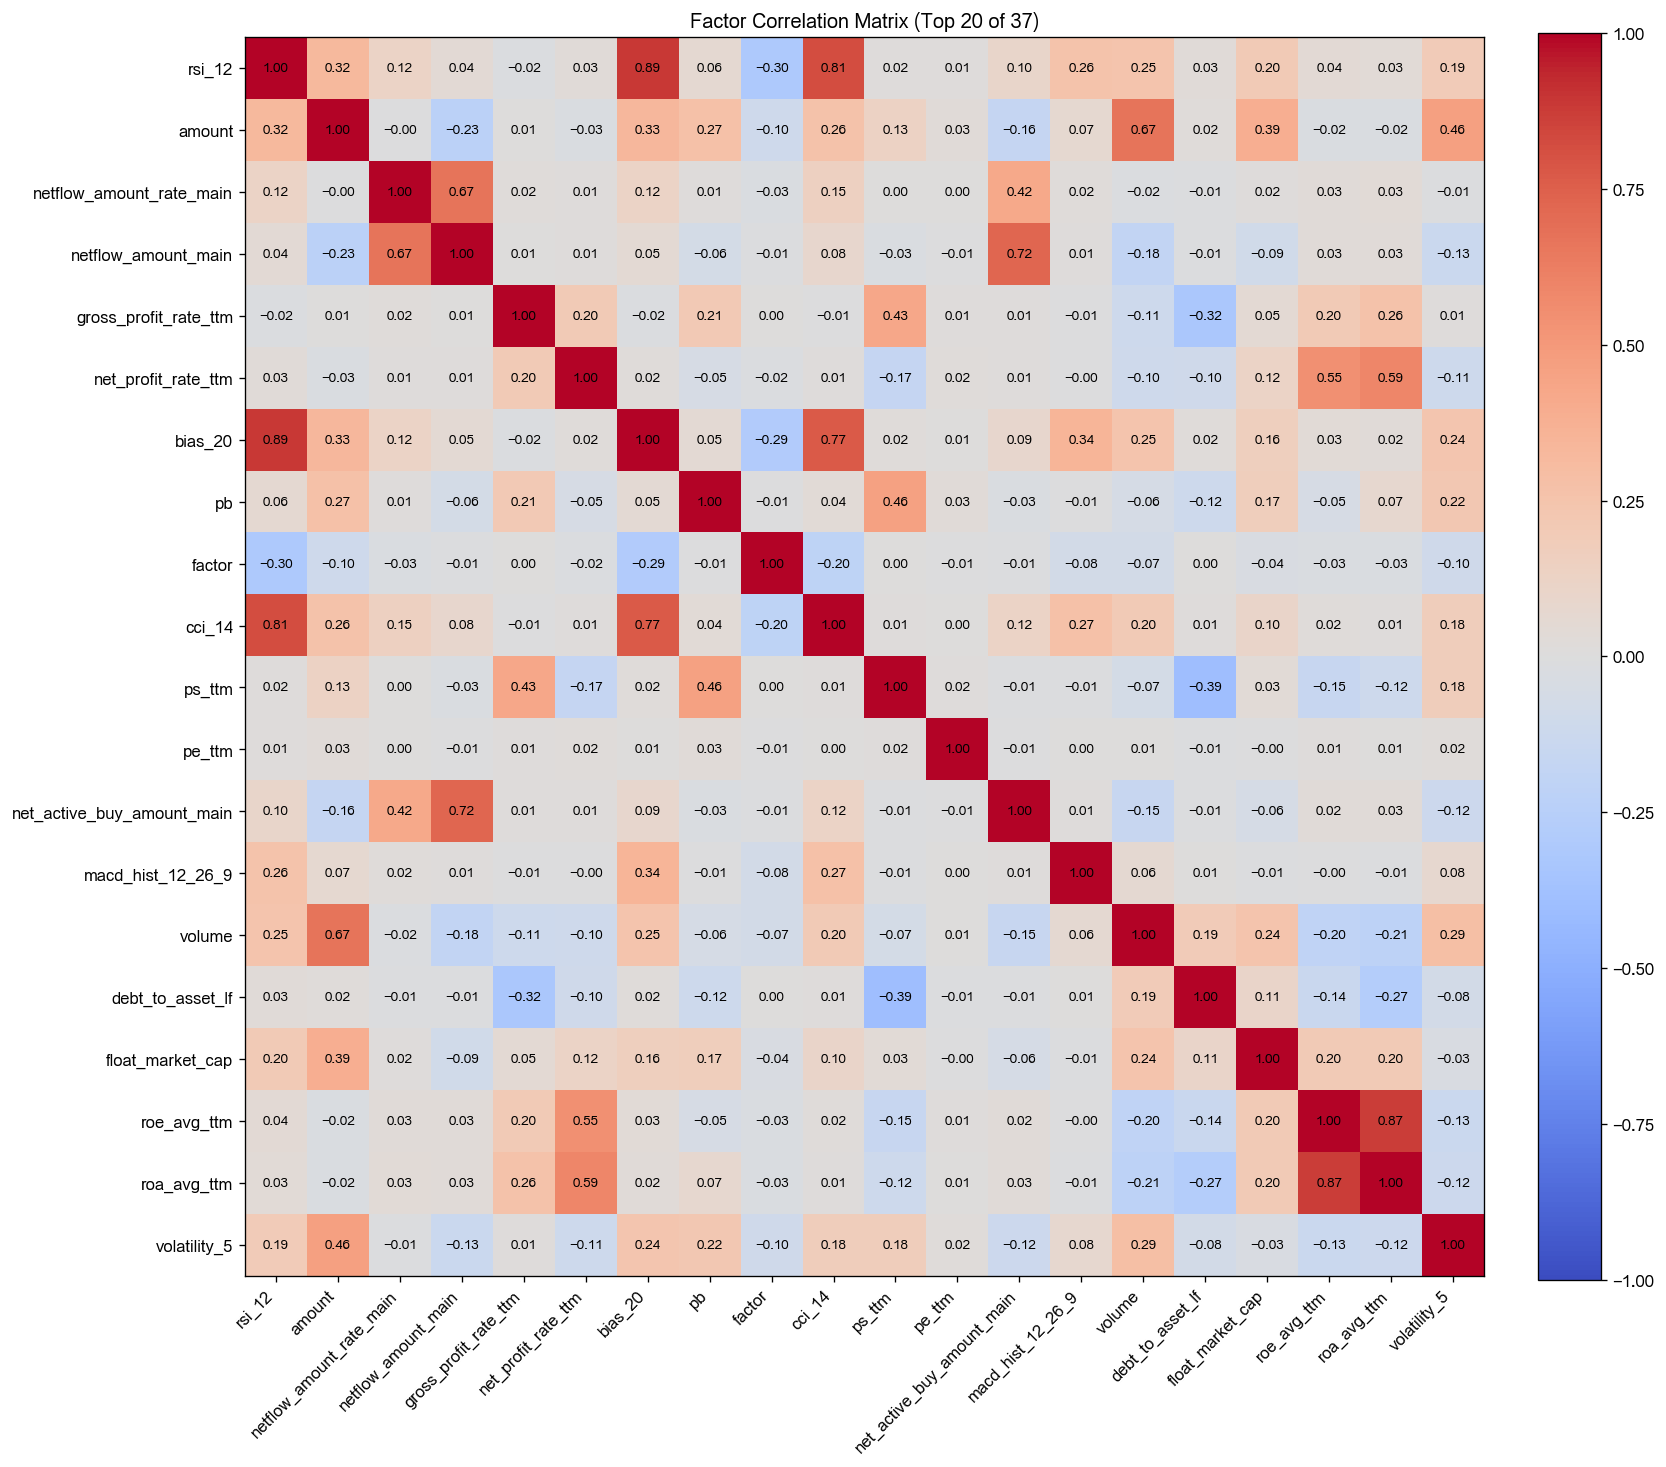

[2026-08-05 18:34:16] [warning  ] 返回的Outputs实例(size=35395609) 大于 64K, 将不会被缓存
[2026-08-05 18:34:16] [info     ] bigalpha_eval.v4 运行完成 [17.905s].


In [3]:
import dai
import numpy as np
import pandas as pd
from bigmodule import M

def ideal_reversal(ret, amt, window=20, min_periods=10):
    """
    理想反转：每个交易日回看过去 window 天，
    按窗口内成交额中位数把日子分成「高成交日 / 低成交日」两组，
    factor = -(高成交日累计收益 - 低成交日累计收益)
    逻辑：放量日涨上去的是资金推动、容易回吐；缩量日涨上去的更可能延续。
    """
    n = len(ret)
    out = np.full(n, np.nan)
    for i in range(n):
        s = max(0, i - window + 1)
        r = ret[s:i + 1]
        a = amt[s:i + 1]
        m = np.isfinite(r) & np.isfinite(a)
        if m.sum() < min_periods:
            continue
        r = r[m]
        a = a[m]
        med = np.median(a)
        high = a >= med
        out[i] = -(r[high].sum() - r[~high].sum())
    return out


def main(datasources, start_date, end_date):
    bar1m_table = datasources['bar1m']

    # 20 日滚动窗口 → 向前多取 60 天热身期，算完再裁剪
    sd = pd.to_datetime(start_date) - pd.Timedelta(days=60)
    ed = pd.to_datetime(end_date)

    # 分钟线聚合成日频：收盘价（当天最后一根分钟K线的close）+ 全天成交额
    sql = """
    SELECT date::DATE::DATETIME AS date,
           instrument,
           argmax(close, date) AS day_close,
           SUM(amount) AS day_amount
    FROM {bar1m_table}
    GROUP BY date::DATE, instrument
    HAVING COUNT(*) >= 100
    """.format(bar1m_table=bar1m_table)

    # 按月分段取数，防止临时文件撑爆磁盘
    bounds = [b for b in pd.date_range(sd, ed, freq='MS') if b > sd]
    bounds = [sd] + bounds + [ed + pd.Timedelta(seconds=1)]
    dfs = []
    for i in range(len(bounds) - 1):
        cs, ce = bounds[i], bounds[i + 1] - pd.Timedelta(seconds=1)
        dfs.append(dai.query(
            sql,
            filters={'date': [cs.strftime('%Y-%m-%d %H:%M:%S'),
                              ce.strftime('%Y-%m-%d %H:%M:%S')]}
        ).df())
    df = pd.concat(dfs, ignore_index=True)

    # 日收益 = 今收 / 昨收 - 1（按股票分组）
    df = df.sort_values(['instrument', 'date']).reset_index(drop=True)
    df['ret'] = df.groupby('instrument')['day_close'].pct_change()

    # 逐股票计算理想反转
    def _calc(g):
        r = g['ret'].to_numpy(dtype=float)
        a = g['day_amount'].to_numpy(dtype=float)
        return pd.Series(ideal_reversal(r, a), index=g.index)

    df['factor'] = df.groupby('instrument', group_keys=False).apply(_calc)

    # 裁掉热身期
    df = df[df['date'] >= pd.to_datetime(start_date)]

    # 对齐股票池 + inf 防御
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]}
    ).df()
    df = pd.merge(df[['date', 'instrument', 'factor']], stk_pool,
                  how='right', on=['date', 'instrument'])
    df['factor'] = df['factor'].replace([np.inf, -np.inf], np.nan)

    return df[['date', 'instrument', 'factor']]


if __name__ == '__main__':
    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'
    factor_data = main(datasources, start_date, end_date)
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]}
    ).df()
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True
    )